In [22]:
import pandas as pd
import numpy as np
import ast
import os
from pathlib import Path
import matplotlib.pyplot as plt

class LineCuttingAnalyzer:
    def __init__(self, level0_dir="all_data/paper_data", level1_dir="all_data/09-2025 First test level 1"):
        self.level0_dir = Path(level0_dir)
        self.level1_dir = Path(level1_dir)
        self.data = {}
        
    def parse_csv_line(self, line):
        """Parse a CSV line with format: temperature, "Dict(...)" """
        parts = line.strip().split(',', 1)
        temp = float(parts[0])
        dict_str = parts[1].strip('"')
        # Clean up the dict string format
        dict_str = dict_str.replace("Dict(", "{").replace(")", "}")
        dict_str = dict_str.replace(" => ", ": ")
        return temp, ast.literal_eval(dict_str)
    
    def load_data(self):
        """Load data from both directories"""
        for level, directory in [("level0", self.level0_dir), ("level1", self.level1_dir)]:
            self.data[level] = {}
            
            # Get all CSV files, excluding collision files and non-map files
            csv_files = list(directory.glob("*.csv"))
            
            for file_path in csv_files:
                # Skip collision files and other non-map files
                if (file_path.name.startswith("collisions_") or 
                    file_path.name in ["data.csv", "olddata.csv"]):
                    continue
                    
                map_name = file_path.stem.replace("_0.0001", "")  # Remove temperature suffix
                
                with open(file_path, 'r') as f:
                    line = f.readline().strip()
                    if line:
                        temp, run_data = self.parse_csv_line(line)
                        self.data[level][map_name] = run_data
        
        print(f"Loaded {len(self.data['level0'])} level0 maps and {len(self.data['level1'])} level1 maps")
    
    def get_completion_times(self, level, map_name):
        """Get completion times for all agents across all runs for a specific map"""
        if map_name not in self.data[level]:
            return None
        
        run_data = self.data[level][map_name]
        all_times = []
        
        # Extract completion times from all runs
        for run_id, agents in run_data.items():
            run_times = list(agents.values())
            all_times.extend(run_times)
        
        return np.array(all_times)
    
    def calculate_aggregate_welfare(self, level, map_name, baseline_level="level0", baseline_map=None):
        """Calculate aggregate welfare change compared to baseline"""
        if baseline_map is None:
            baseline_map = map_name
            
        current_times = self.get_completion_times(level, map_name)
        baseline_times = self.get_completion_times(baseline_level, baseline_map)
        
        if current_times is None or baseline_times is None:
            return None
        
        # Mean completion time improvement (negative means faster)
        current_mean = np.mean(current_times)
        baseline_mean = np.mean(baseline_times)
        
        # Normalize by baseline (as in paper's Equation 3)
        welfare_change = -(current_mean - baseline_mean) / baseline_mean
        
        return welfare_change
    
    def calculate_inequality(self, level, map_name):
        """Calculate inequality within each run, then average"""
        if map_name not in self.data[level]:
            return None
        
        run_data = self.data[level][map_name]
        inequalities = []
        
        for run_id, agents in run_data.items():
            times = np.array(list(agents.values()))
            inequality = np.max(times) - np.min(times)
            inequalities.append(inequality)
        
        return np.mean(inequalities)
    
    def compare_map(self, map_name):
        """Compare a specific map between level 0 and level 1"""
        print(f"\n=== Comparison for {map_name} ===")
        
        # Completion times
        times_l0 = self.get_completion_times("level0", map_name)
        times_l1 = self.get_completion_times("level1", map_name)
        
        if times_l0 is None or times_l1 is None:
            print("Map not found in both datasets")
            return None
        
        print(f"Level 0 - Mean: {np.mean(times_l0):.1f}, Std: {np.std(times_l0):.1f}")
        print(f"Level 1 - Mean: {np.mean(times_l1):.1f}, Std: {np.std(times_l1):.1f}")
        
        # Welfare change
        welfare_change = self.calculate_aggregate_welfare("level1", map_name)
        print(f"Welfare change (L1 vs L0): {welfare_change:.3f}")
        
        # Inequality
        ineq_l0 = self.calculate_inequality("level0", map_name)
        ineq_l1 = self.calculate_inequality("level1", map_name)
        print(f"Inequality L0: {ineq_l0:.1f}, L1: {ineq_l1:.1f}, Change: {ineq_l1 - ineq_l0:.1f}")
        
        return {
            'map': map_name,
            'welfare_change': welfare_change,
            'inequality_l0': ineq_l0,
            'inequality_l1': ineq_l1,
            'inequality_change': ineq_l1 - ineq_l0,
            'mean_time_l0': np.mean(times_l0),
            'mean_time_l1': np.mean(times_l1)
        }
    
    def compare_map_group(self, prefix="no_line"):
        """Compare all maps starting with a prefix"""
        results = []
        
        # Find all maps with this prefix in both datasets
        common_maps = set(self.data["level0"].keys()) & set(self.data["level1"].keys())
        filtered_maps = [m for m in common_maps if m.startswith(prefix)]
        
        print(f"\nFound {len(filtered_maps)} maps with prefix '{prefix}': {filtered_maps}")
        
        for map_name in sorted(filtered_maps):
            result = self.compare_map(map_name)
            if result:
                results.append(result)
        
        # Summary statistics
        if results:
            df = pd.DataFrame(results)
            print(f"\n=== Summary for {prefix} maps ===")
            print(f"Average welfare change: {df['welfare_change'].mean():.3f} ± {df['welfare_change'].std():.3f}")
            print(f"Average inequality change: {df['inequality_change'].mean():.1f} ± {df['inequality_change'].std():.1f}")
            
            return df
        
        return None
    
    def plot_comparison(self, results_df, metric='welfare_change'):
        """Plot comparison results"""
        plt.figure(figsize=(10, 6))
        plt.bar(range(len(results_df)), results_df[metric])
        plt.xlabel('Map Index')
        plt.ylabel(metric.replace('_', ' ').title())
        plt.title(f'{metric.replace("_", " ").title()} Comparison: Level 1 vs Level 0')
        plt.xticks(range(len(results_df)), results_df['map'], rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    
    def list_available_maps(self):
        """List all available maps in both datasets"""
        print("Level 0 maps:", sorted(self.data.get("level0", {}).keys()))
        print("Level 1 maps:", sorted(self.data.get("level1", {}).keys()))
        
        common = set(self.data.get("level0", {}).keys()) & set(self.data.get("level1", {}).keys())
        print(f"Common maps ({len(common)}):", sorted(common))



Loaded 29 level0 maps and 29 level1 maps
Level 0 maps: ['10esque_test.pddl', '7esque_test.pddl', '9esque_test.pddl', 'maybe_4.pddl', 'maybe_5.pddl', 'maybe_6.pddl', 'new_maybe_1.pddl', 'new_maybe_2.pddl', 'new_maybe_3.pddl', 'new_maybe_4.pddl', 'new_maybe_5.pddl', 'new_maybe_6.pddl', 'no_line_1_test.pddl', 'no_line_2_test.pddl', 'no_line_3_test.pddl', 'no_line_A.pddl', 'no_line_B.pddl', 'no_line_C.pddl', 'no_line_D.pddl', 'yes_line_10_test.pddl', 'yes_line_7_test.pddl', 'yes_line_8_test.pddl', 'yes_line_9_test.pddl', 'yes_line_A.pddl', 'yes_line_B.pddl', 'yes_line_C.pddl', 'yes_line_D.pddl', 'yes_line_E.pddl', 'yes_line_F.pddl']
Level 1 maps: ['10esque_test.pddl', '7esque_test.pddl', '9esque_test.pddl', 'maybe_4.pddl', 'maybe_5.pddl', 'maybe_6.pddl', 'new_maybe_1.pddl', 'new_maybe_2.pddl', 'new_maybe_3.pddl', 'new_maybe_4.pddl', 'new_maybe_5.pddl', 'new_maybe_6.pddl', 'no_line_1_test.pddl', 'no_line_2_test.pddl', 'no_line_3_test.pddl', 'no_line_A.pddl', 'no_line_B.pddl', 'no_line_C.pdd

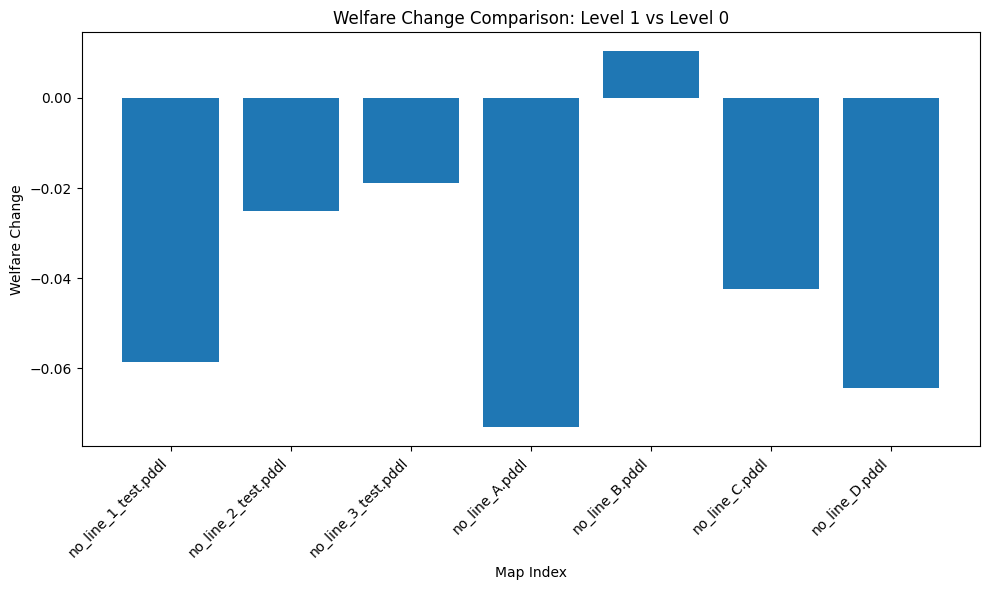

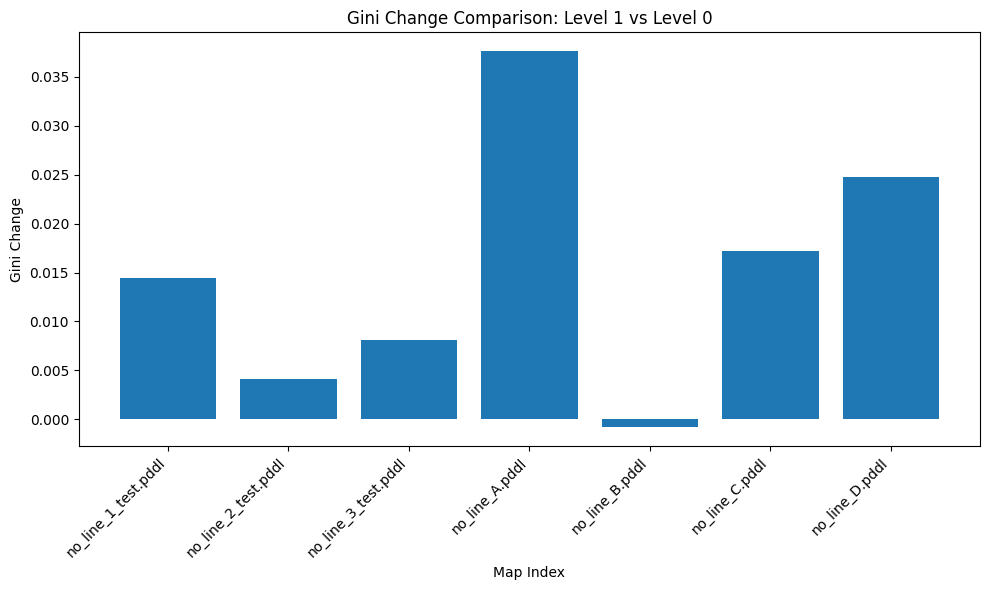

In [56]:
# Usage example:
analyzer = LineCuttingAnalyzer()
analyzer.load_data()
analyzer.list_available_maps()

# # Compare a specific map
analyzer.compare_map("no_line_1_test.pddl")

# # Compare all no_line maps
no_line_results = analyzer.compare_map_group("no_line")

# # Compare all yes_line maps  
yes_line_results = analyzer.compare_map_group("yes_line")

# # Plot results
if no_line_results is not None:
     analyzer.plot_comparison(no_line_results, 'welfare_change')
     analyzer.plot_comparison(no_line_results, 'gini_change')

In [57]:
import pandas as pd
import numpy as np
import ast
import os
from pathlib import Path
import matplotlib.pyplot as plt

class LineCuttingAnalyzer:
    def __init__(self, level0_dir="all_data/paper_data", level1_dir="all_data/09-2025 First test level 1"):
        self.level0_dir = Path(level0_dir)
        self.level1_dir = Path(level1_dir)
        self.data = {}
        
    def parse_csv_line(self, line):
        """Parse a CSV line with format: temperature, "Dict(...)" """
        parts = line.strip().split(',', 1)
        temp = float(parts[0])
        dict_str = parts[1].strip('"')
        # Clean up the dict string format
        dict_str = dict_str.replace("Dict(", "{").replace(")", "}")
        dict_str = dict_str.replace(" => ", ": ")
        return temp, ast.literal_eval(dict_str)
    
    def load_data(self):
        """Load data from both directories"""
        for level, directory in [("level0", self.level0_dir), ("level1", self.level1_dir)]:
            self.data[level] = {}
            
            # Get all CSV files, excluding collision files and non-map files
            csv_files = list(directory.glob("*.csv"))
            
            for file_path in csv_files:
                # Skip collision files and other non-map files
                if (file_path.name.startswith("collisions_") or 
                    file_path.name in ["data.csv", "olddata.csv"]):
                    continue
                    
                map_name = file_path.stem.replace("_0.0001", "")  # Remove temperature suffix
                
                with open(file_path, 'r') as f:
                    line = f.readline().strip()
                    if line:
                        temp, run_data = self.parse_csv_line(line)
                        self.data[level][map_name] = run_data
        
        print(f"Loaded {len(self.data['level0'])} level0 maps and {len(self.data['level1'])} level1 maps")
    
    def get_completion_times(self, level, map_name):
        """Get completion times for all agents across all runs for a specific map"""
        if map_name not in self.data[level]:
            return None
        
        run_data = self.data[level][map_name]
        all_times = []
        
        # Extract completion times from all runs
        for run_id, agents in run_data.items():
            run_times = list(agents.values())
            all_times.extend(run_times)
        
        return np.array(all_times)
    
    def calculate_aggregate_welfare(self, level, map_name, baseline_level="level0", baseline_map=None):
        """Calculate aggregate welfare change compared to baseline"""
        if baseline_map is None:
            baseline_map = map_name
            
        current_times = self.get_completion_times(level, map_name)
        baseline_times = self.get_completion_times(baseline_level, baseline_map)
        
        if current_times is None or baseline_times is None:
            return None
        
        # Mean completion time improvement (negative means faster)
        current_mean = np.mean(current_times)
        baseline_mean = np.mean(baseline_times)
        
        # Normalize by baseline (as in paper's Equation 3)
        welfare_change = -(current_mean - baseline_mean) / baseline_mean
        
        return welfare_change
    
    def calculate_inequality_change(self, level, map_name, baseline_level="level0", baseline_map=None):
        """Calculate inequality change compared to baseline (following paper's Equation 6)"""
        if baseline_map is None:
            baseline_map = map_name
            
        if map_name not in self.data[level] or baseline_map not in self.data[baseline_level]:
            return None
        
        # Current scenario inequality
        current_data = self.data[level][map_name]
        current_inequalities = []
        current_last_times = []
        
        for run_id, agents in current_data.items():
            times = np.array(list(agents.values()))
            inequality = np.max(times) - np.min(times)
            current_inequalities.append(inequality)
            current_last_times.append(np.max(times))
        
        # Baseline scenario inequality
        baseline_data = self.data[baseline_level][baseline_map]
        baseline_inequalities = []
        baseline_last_times = []
        
        for run_id, agents in baseline_data.items():
            times = np.array(list(agents.values()))
            inequality = np.max(times) - np.min(times)
            baseline_inequalities.append(inequality)
            baseline_last_times.append(np.max(times))
        
        # Calculate change in inequality, normalized by baseline last completion time
        current_ineq_norm = np.mean(current_inequalities) / np.mean(baseline_last_times)
        baseline_ineq_norm = np.mean(baseline_inequalities) / np.mean(baseline_last_times)
        
        return current_ineq_norm - baseline_ineq_norm
    
    def gini_coefficient(self, times):
        """Calculate Gini coefficient for inequality measurement"""
        if len(times) == 0:
            return 0
        total = 0
        for i, xi in enumerate(times[:-1], 1):
            total += np.sum(np.abs(xi - times[i:]))
        return total / (len(times) ** 2 * np.mean(times))
    
    def calculate_gini_change(self, level, map_name, baseline_level="level0", baseline_map=None):
        """Calculate change in Gini coefficient between scenarios (averaged per run like original code)"""
        if baseline_map is None:
            baseline_map = map_name
            
        if map_name not in self.data[level] or baseline_map not in self.data[baseline_level]:
            return None
        
        # Current scenario Gini - calculate per run, then average
        current_data = self.data[level][map_name]
        current_ginis = []
        
        for run_id, agents in current_data.items():
            times = np.array(list(agents.values()))  # 8 agents per run
            gini = self.gini_coefficient(times)
            current_ginis.append(gini)
        
        # Baseline scenario Gini - calculate per run, then average  
        baseline_data = self.data[baseline_level][baseline_map]
        baseline_ginis = []
        
        for run_id, agents in baseline_data.items():
            times = np.array(list(agents.values()))  # 8 agents per run
            gini = self.gini_coefficient(times)
            baseline_ginis.append(gini)
        
        # Return difference in average Gini coefficients
        return np.mean(current_ginis) - np.mean(baseline_ginis)
    
    def calculate_raw_inequality(self, level, map_name):
        """Calculate raw inequality (max - min completion time) for comparison"""
        if map_name not in self.data[level]:
            return None
        
        run_data = self.data[level][map_name]
        inequalities = []
        
        for run_id, agents in run_data.items():
            times = np.array(list(agents.values()))
            inequality = np.max(times) - np.min(times)
            inequalities.append(inequality)
        
        return np.mean(inequalities)
        """Calculate raw inequality (max - min completion time) for comparison"""
        if map_name not in self.data[level]:
            return None
        
        run_data = self.data[level][map_name]
        inequalities = []
        
        for run_id, agents in run_data.items():
            times = np.array(list(agents.values()))
            inequality = np.max(times) - np.min(times)
            inequalities.append(inequality)
        
        return np.mean(inequalities)
    
    def compare_map(self, map_name):
        """Compare a specific map between level 0 and level 1"""
        print(f"\n=== Comparison for {map_name} ===")
        
        # Completion times
        times_l0 = self.get_completion_times("level0", map_name)
        times_l1 = self.get_completion_times("level1", map_name)
        
        if times_l0 is None or times_l1 is None:
            print("Map not found in both datasets")
            return None
        
        print(f"Level 0 - Mean: {np.mean(times_l0):.1f}, Std: {np.std(times_l0):.1f}")
        print(f"Level 1 - Mean: {np.mean(times_l1):.1f}, Std: {np.std(times_l1):.1f}")
        
        # Welfare change
        welfare_change = self.calculate_aggregate_welfare("level1", map_name)
        print(f"Welfare change (L1 vs L0): {welfare_change:.3f}")
        
        # Inequality measures
        raw_ineq_l0 = self.calculate_raw_inequality("level0", map_name)
        raw_ineq_l1 = self.calculate_raw_inequality("level1", map_name)
        inequality_change = self.calculate_inequality_change("level1", map_name)
        gini_change = self.calculate_gini_change("level1", map_name)
        
        print(f"Raw inequality L0: {raw_ineq_l0:.1f}, L1: {raw_ineq_l1:.1f}")
        print(f"Normalized inequality change (paper method): {inequality_change:.3f}")
        print(f"Gini coefficient change: {gini_change:.3f}")
        
        return {
            'map': map_name,
            'welfare_change': welfare_change,
            'raw_inequality_l0': raw_ineq_l0,
            'raw_inequality_l1': raw_ineq_l1,
            'inequality_change': inequality_change,
            'gini_change': gini_change,
            'mean_time_l0': np.mean(times_l0),
            'mean_time_l1': np.mean(times_l1)
        }
    
    def compare_map_group(self, prefix="no_line"):
        """Compare all maps starting with a prefix"""
        results = []
        
        # Find all maps with this prefix in both datasets
        common_maps = set(self.data["level0"].keys()) & set(self.data["level1"].keys())
        filtered_maps = [m for m in common_maps if m.startswith(prefix)]
        
        print(f"\nFound {len(filtered_maps)} maps with prefix '{prefix}': {filtered_maps}")
        
        for map_name in sorted(filtered_maps):
            result = self.compare_map(map_name)
            if result:
                results.append(result)
        
        # Summary statistics
        if results:
            df = pd.DataFrame(results)
            print(f"\n=== Summary for {prefix} maps ===")
            print(f"Average welfare change: {df['welfare_change'].mean():.3f} ± {df['welfare_change'].std():.3f}")
            print(f"Average inequality change: {df['inequality_change'].mean():.3f} ± {df['inequality_change'].std():.3f}")
            
            return df
        
        return None
    
    def plot_comparison(self, results_df, metric='welfare_change'):
        """Plot comparison results"""
        plt.figure(figsize=(10, 6))
        plt.bar(range(len(results_df)), results_df[metric])
        plt.xlabel('Map Index')
        plt.ylabel(metric.replace('_', ' ').title())
        plt.title(f'{metric.replace("_", " ").title()} Comparison: Level 1 vs Level 0')
        plt.xticks(range(len(results_df)), results_df['map'], rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    
    def list_available_maps(self):
        """List all available maps in both datasets"""
        print("Level 0 maps:", sorted(self.data.get("level0", {}).keys()))
        print("Level 1 maps:", sorted(self.data.get("level1", {}).keys()))
        
        common = set(self.data.get("level0", {}).keys()) & set(self.data.get("level1", {}).keys())
        print(f"Common maps ({len(common)}):", sorted(common))

# Usage example:
# analyzer = LineCuttingAnalyzer()
# analyzer.load_data()
# analyzer.list_available_maps()

# # Compare a specific map
# analyzer.compare_map("no_line_1_test")

# # Compare all no_line maps
# no_line_results = analyzer.compare_map_group("no_line")

# # Compare all yes_line maps  
# yes_line_results = analyzer.compare_map_group("yes_line")

# # Plot results
# if no_line_results is not None:
#     analyzer.plot_comparison(no_line_results, 'welfare_change')
#     analyzer.plot_comparison(no_line_results, 'inequality_change')

In [58]:
# Usage example:
analyzer = LineCuttingAnalyzer()
analyzer.load_data()
analyzer.list_available_maps()

# # Compare a specific map
analyzer.compare_map("no_line_1_test.pddl")


Loaded 29 level0 maps and 29 level1 maps
Level 0 maps: ['10esque_test.pddl', '7esque_test.pddl', '9esque_test.pddl', 'maybe_4.pddl', 'maybe_5.pddl', 'maybe_6.pddl', 'new_maybe_1.pddl', 'new_maybe_2.pddl', 'new_maybe_3.pddl', 'new_maybe_4.pddl', 'new_maybe_5.pddl', 'new_maybe_6.pddl', 'no_line_1_test.pddl', 'no_line_2_test.pddl', 'no_line_3_test.pddl', 'no_line_A.pddl', 'no_line_B.pddl', 'no_line_C.pddl', 'no_line_D.pddl', 'yes_line_10_test.pddl', 'yes_line_7_test.pddl', 'yes_line_8_test.pddl', 'yes_line_9_test.pddl', 'yes_line_A.pddl', 'yes_line_B.pddl', 'yes_line_C.pddl', 'yes_line_D.pddl', 'yes_line_E.pddl', 'yes_line_F.pddl']
Level 1 maps: ['10esque_test.pddl', '7esque_test.pddl', '9esque_test.pddl', 'maybe_4.pddl', 'maybe_5.pddl', 'maybe_6.pddl', 'new_maybe_1.pddl', 'new_maybe_2.pddl', 'new_maybe_3.pddl', 'new_maybe_4.pddl', 'new_maybe_5.pddl', 'new_maybe_6.pddl', 'no_line_1_test.pddl', 'no_line_2_test.pddl', 'no_line_3_test.pddl', 'no_line_A.pddl', 'no_line_B.pddl', 'no_line_C.pdd

{'map': 'no_line_1_test.pddl',
 'welfare_change': np.float64(-0.05856832971800424),
 'raw_inequality_l0': np.float64(12.4),
 'raw_inequality_l1': np.float64(15.4),
 'inequality_change': np.float64(0.10067114093959734),
 'gini_change': np.float64(0.01445995630159956),
 'mean_time_l0': np.float64(23.05),
 'mean_time_l1': np.float64(24.4)}

In [59]:
# # Compare all no_line maps
no_line_results = analyzer.compare_map_group("no_line")

# # Compare all yes_line maps  
yes_line_results = analyzer.compare_map_group("yes_line")

# # Compare all maybe maps (different nomenclatures... plus what does esque do?)
maybe_line_results = analyzer.compare_map_group("maybe")
maybe_results = analyzer.compare_map_group("new_maybe")


Found 7 maps with prefix 'no_line': ['no_line_A.pddl', 'no_line_D.pddl', 'no_line_2_test.pddl', 'no_line_3_test.pddl', 'no_line_C.pddl', 'no_line_1_test.pddl', 'no_line_B.pddl']

=== Comparison for no_line_1_test.pddl ===
Level 0 - Mean: 23.1, Std: 4.0
Level 1 - Mean: 24.4, Std: 5.1
Welfare change (L1 vs L0): -0.059
Raw inequality L0: 12.4, L1: 15.4
Normalized inequality change (paper method): 0.101
Gini coefficient change: 0.014

=== Comparison for no_line_2_test.pddl ===
Level 0 - Mean: 15.9, Std: 4.8
Level 1 - Mean: 16.3, Std: 5.0
Welfare change (L1 vs L0): -0.025
Raw inequality L0: 13.6, L1: 14.0
Normalized inequality change (paper method): 0.017
Gini coefficient change: 0.004

=== Comparison for no_line_3_test.pddl ===
Level 0 - Mean: 23.8, Std: 5.8
Level 1 - Mean: 24.2, Std: 6.3
Welfare change (L1 vs L0): -0.019
Raw inequality L0: 18.8, L1: 20.4
Normalized inequality change (paper method): 0.048
Gini coefficient change: 0.008

=== Comparison for no_line_A.pddl ===
Level 0 - Mean

In [41]:
# Compare all
all_results = analyzer.compare_map_group("")



Found 29 maps with prefix '': ['maybe_5.pddl', 'yes_line_D.pddl', 'new_maybe_1.pddl', '10esque_test.pddl', 'no_line_A.pddl', 'no_line_D.pddl', 'no_line_2_test.pddl', 'yes_line_E.pddl', 'yes_line_A.pddl', 'new_maybe_4.pddl', 'yes_line_F.pddl', 'yes_line_B.pddl', '9esque_test.pddl', 'yes_line_C.pddl', 'no_line_3_test.pddl', 'new_maybe_2.pddl', 'no_line_C.pddl', 'new_maybe_6.pddl', '7esque_test.pddl', 'new_maybe_5.pddl', 'yes_line_7_test.pddl', 'yes_line_10_test.pddl', 'maybe_4.pddl', 'no_line_1_test.pddl', 'maybe_6.pddl', 'yes_line_8_test.pddl', 'new_maybe_3.pddl', 'yes_line_9_test.pddl', 'no_line_B.pddl']

=== Comparison for 10esque_test.pddl ===
Level 0 - Mean: 67.0, Std: 26.7
Level 1 - Mean: 66.7, Std: 27.0
Welfare change (L1 vs L0): 0.005
Raw inequality L0: 78.8, L1: 79.0
Normalized inequality change (paper method): 0.002
Gini coefficient change: -0.001

=== Comparison for 7esque_test.pddl ===
Level 0 - Mean: 39.9, Std: 15.7
Level 1 - Mean: 40.5, Std: 15.5
Welfare change (L1 vs L0):

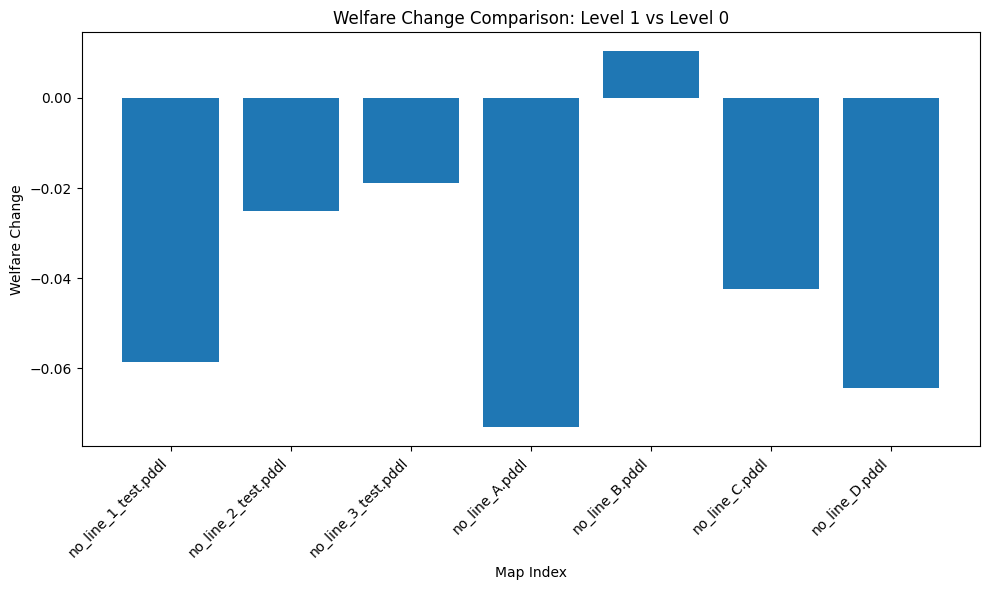

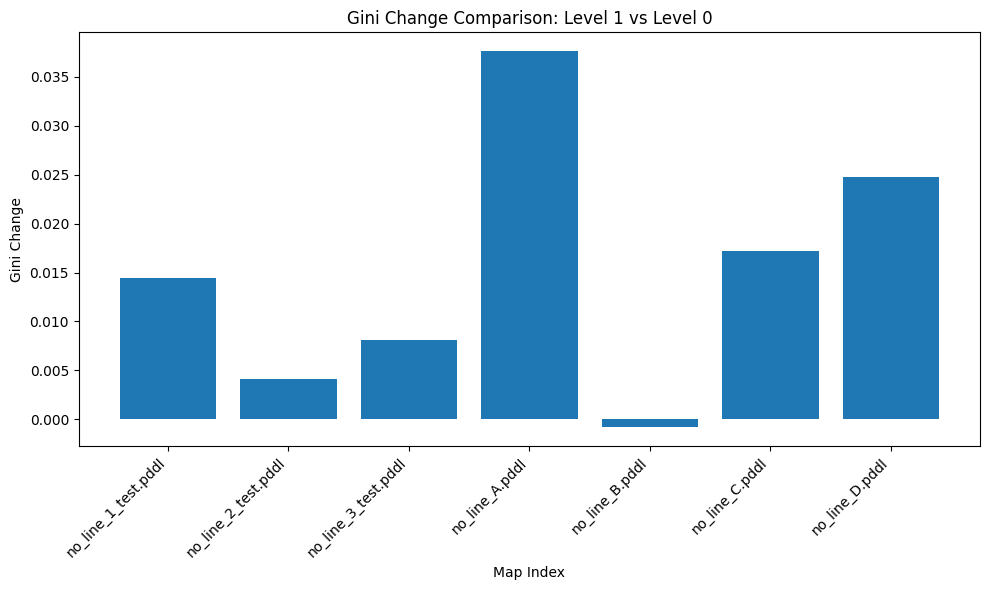

In [60]:
# # Plot results
if no_line_results is not None:
     analyzer.plot_comparison(no_line_results, 'welfare_change')
     analyzer.plot_comparison(no_line_results, 'gini_change')

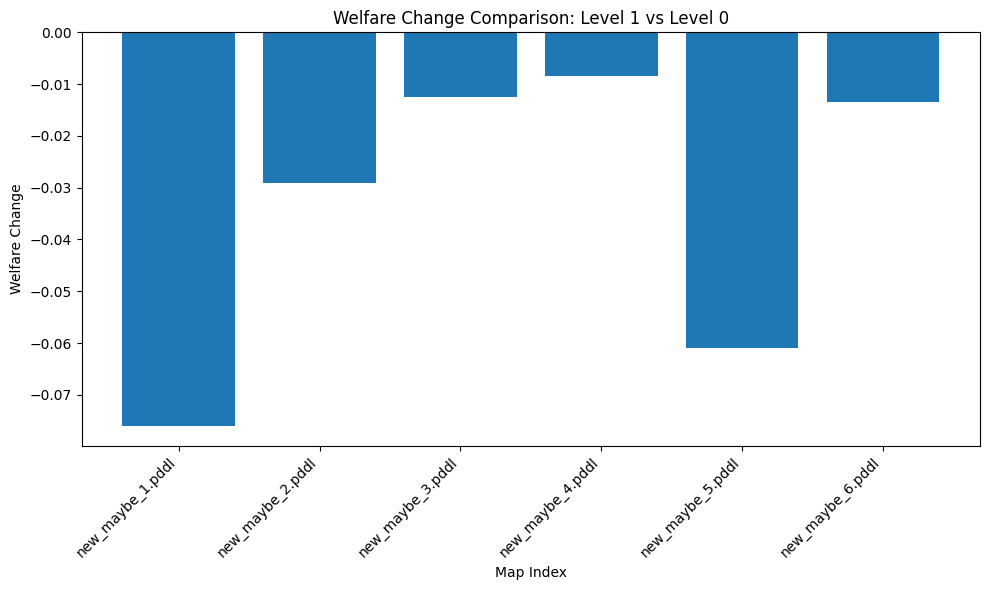

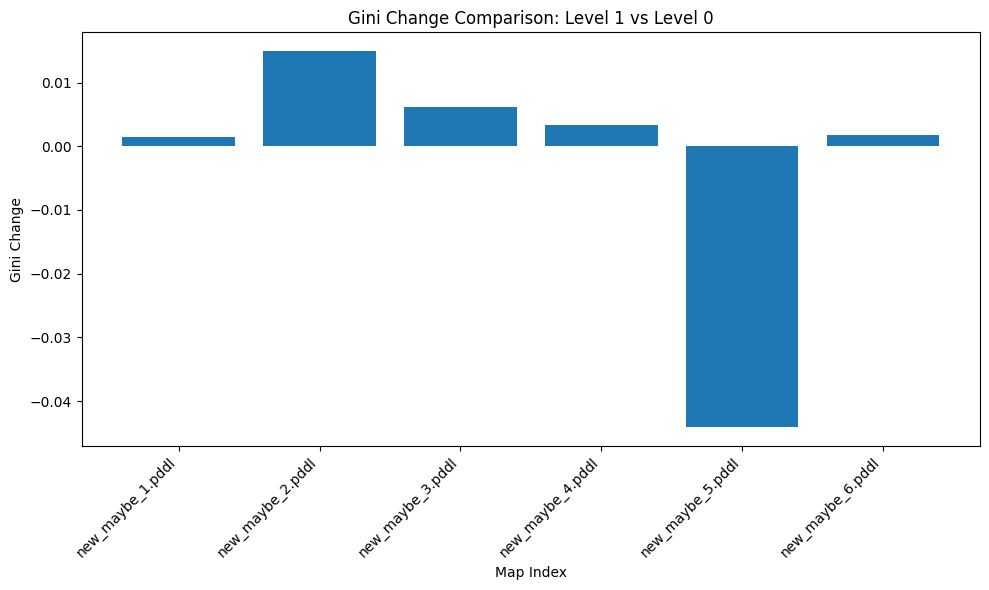

In [61]:
if maybe_results is not None:
     analyzer.plot_comparison(maybe_results, 'welfare_change')
     analyzer.plot_comparison(maybe_results, 'gini_change')

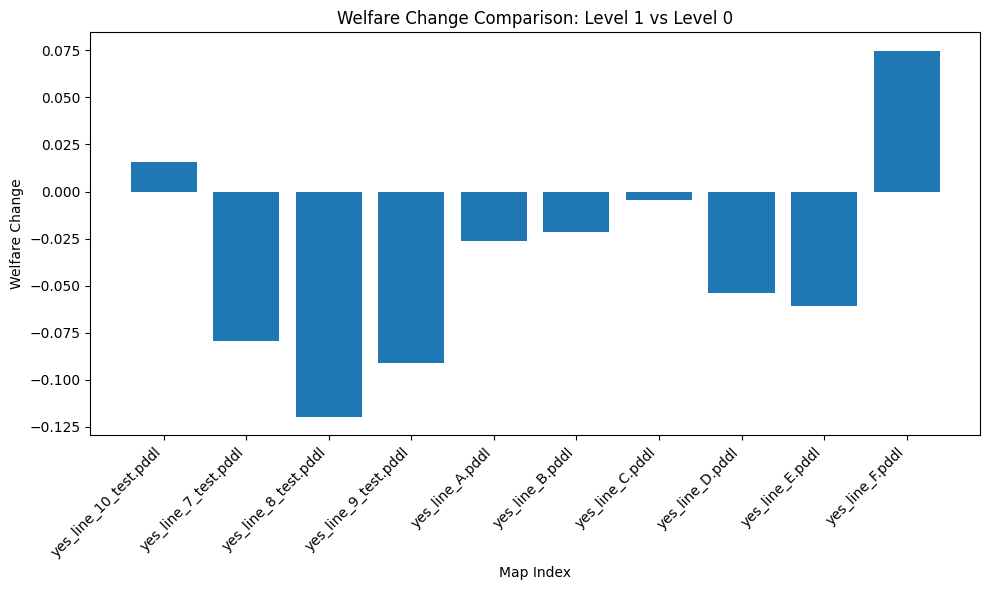

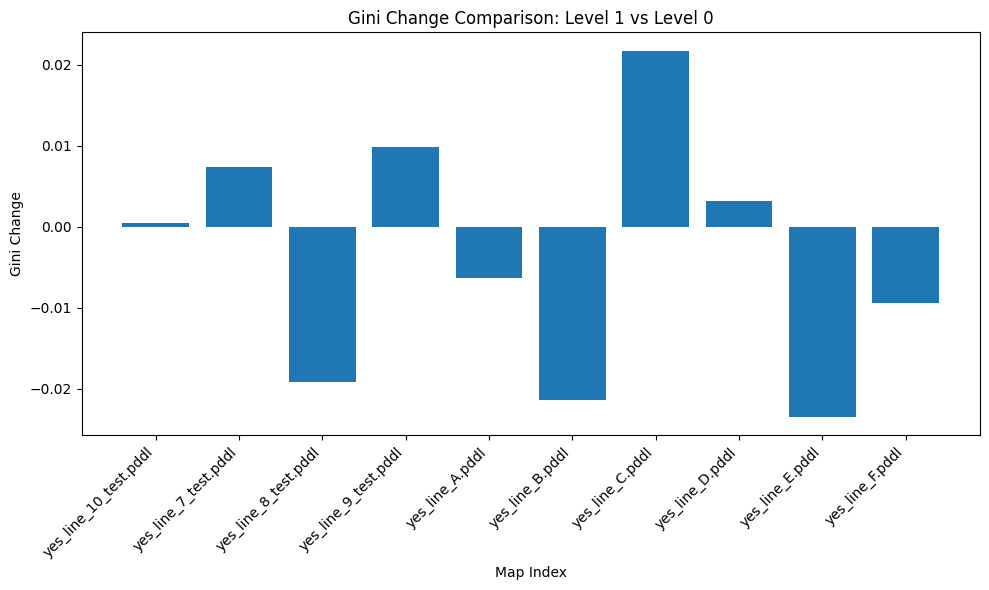

In [62]:
if yes_line_results is not None:
     analyzer.plot_comparison(yes_line_results, 'welfare_change')
     analyzer.plot_comparison(yes_line_results, 'gini_change')

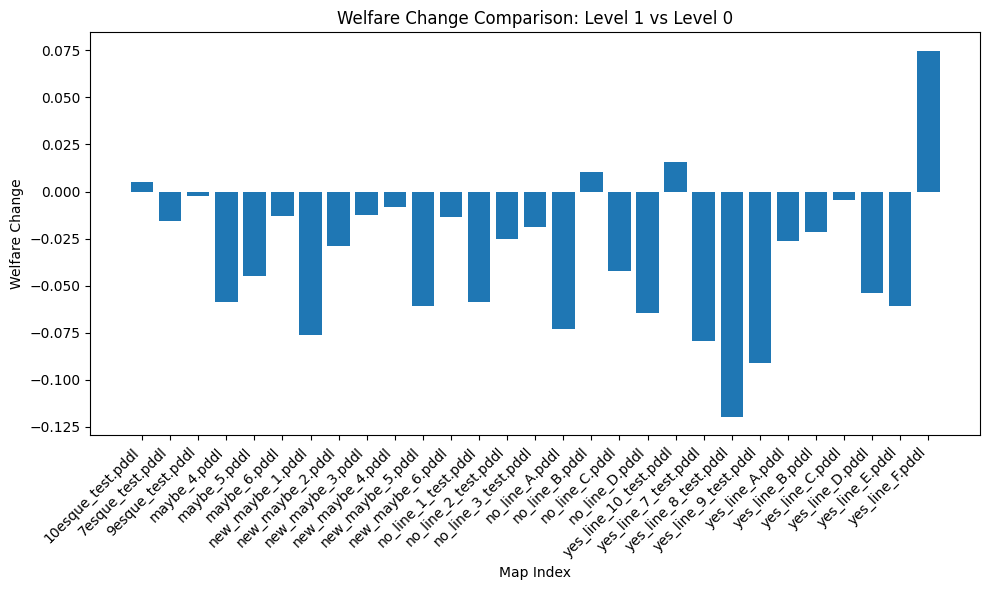

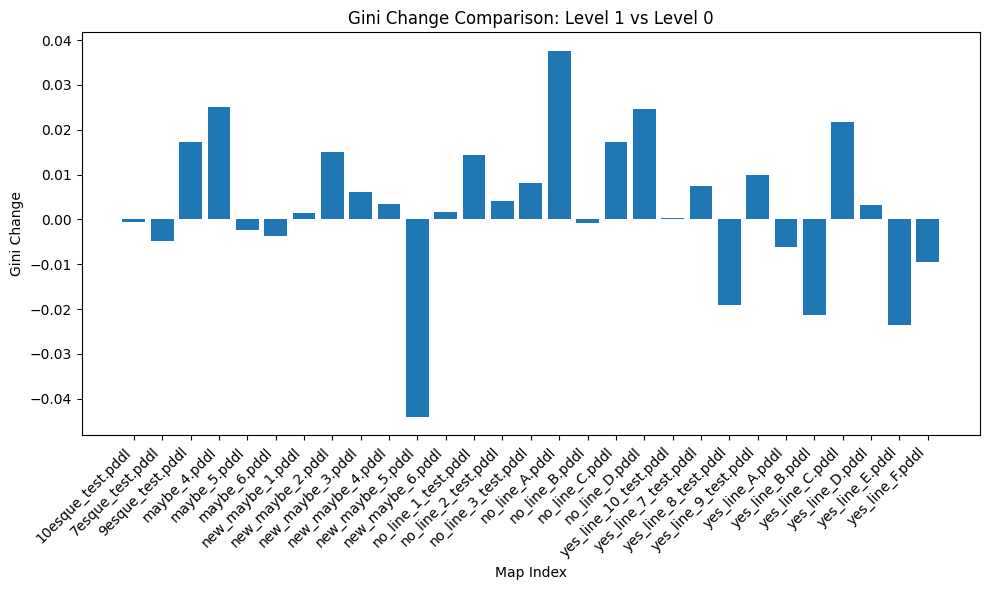

In [42]:
analyzer.plot_comparison(all_results, 'welfare_change')
analyzer.plot_comparison(all_results, 'gini_change')

In [46]:
analyzer = LineCuttingAnalyzer(
    level0_dir="all_data/paper_data", 
    level1_dir="all_data/08-2025 Full test"
)
analyzer.load_data()
analyzer.list_available_maps()

# # Compare a specific map
analyzer.compare_map("no_line_1_test.pddl")

# # Compare all ]maps
all_results = analyzer.compare_map_group("")

Loaded 29 level0 maps and 29 level1 maps
Level 0 maps: ['10esque_test.pddl', '7esque_test.pddl', '9esque_test.pddl', 'maybe_4.pddl', 'maybe_5.pddl', 'maybe_6.pddl', 'new_maybe_1.pddl', 'new_maybe_2.pddl', 'new_maybe_3.pddl', 'new_maybe_4.pddl', 'new_maybe_5.pddl', 'new_maybe_6.pddl', 'no_line_1_test.pddl', 'no_line_2_test.pddl', 'no_line_3_test.pddl', 'no_line_A.pddl', 'no_line_B.pddl', 'no_line_C.pddl', 'no_line_D.pddl', 'yes_line_10_test.pddl', 'yes_line_7_test.pddl', 'yes_line_8_test.pddl', 'yes_line_9_test.pddl', 'yes_line_A.pddl', 'yes_line_B.pddl', 'yes_line_C.pddl', 'yes_line_D.pddl', 'yes_line_E.pddl', 'yes_line_F.pddl']
Level 1 maps: ['10esque_test.pddl', '7esque_test.pddl', '9esque_test.pddl', 'maybe_4.pddl', 'maybe_5.pddl', 'maybe_6.pddl', 'new_maybe_1.pddl', 'new_maybe_2.pddl', 'new_maybe_3.pddl', 'new_maybe_4.pddl', 'new_maybe_5.pddl', 'new_maybe_6.pddl', 'no_line_1_test.pddl', 'no_line_2_test.pddl', 'no_line_3_test.pddl', 'no_line_A.pddl', 'no_line_B.pddl', 'no_line_C.pdd

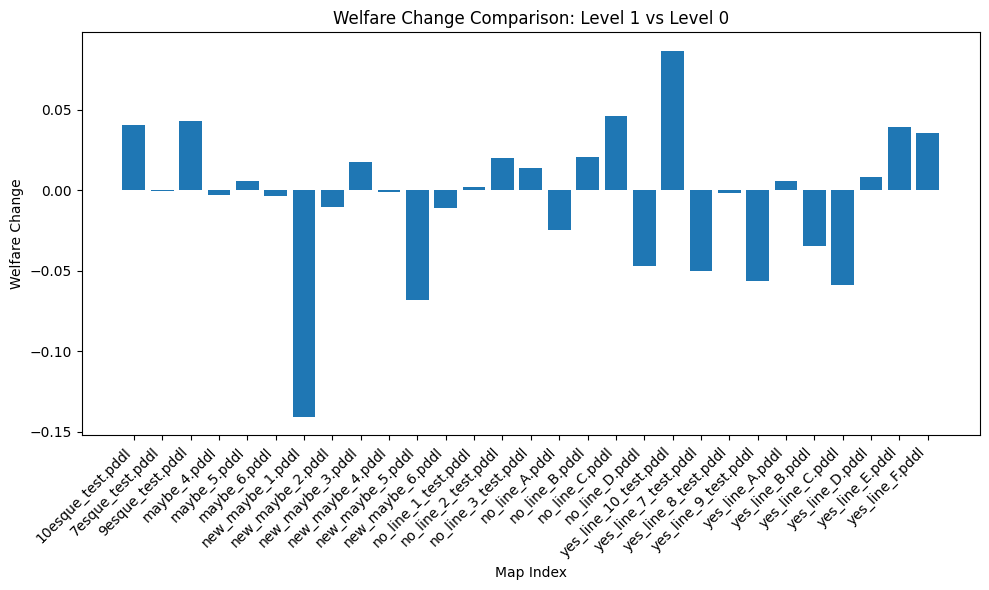

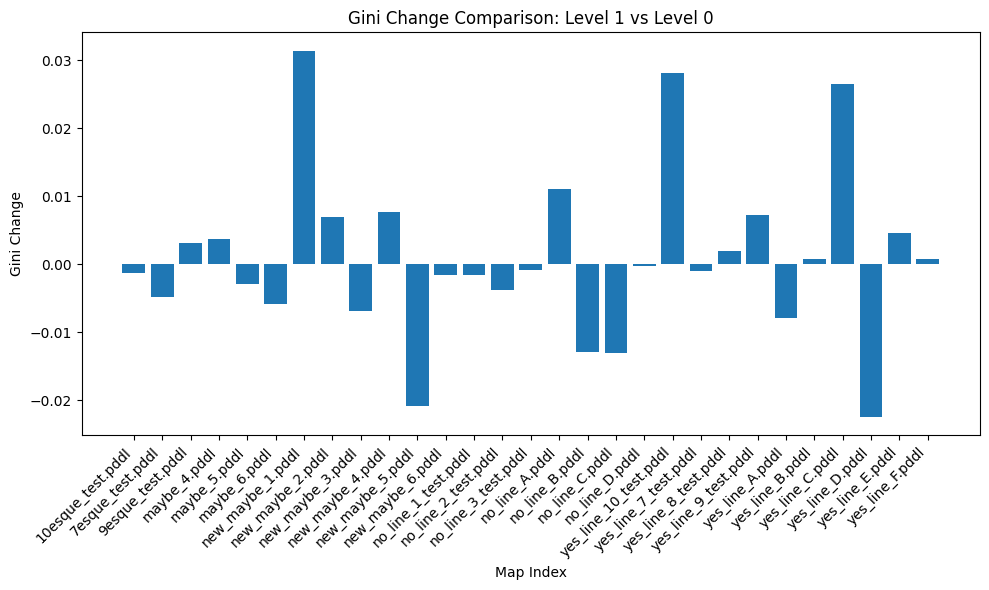

In [53]:
# # Plot results
if all_results is not None:
     analyzer.plot_comparison(all_results, 'welfare_change')
     analyzer.plot_comparison(all_results, 'gini_change')

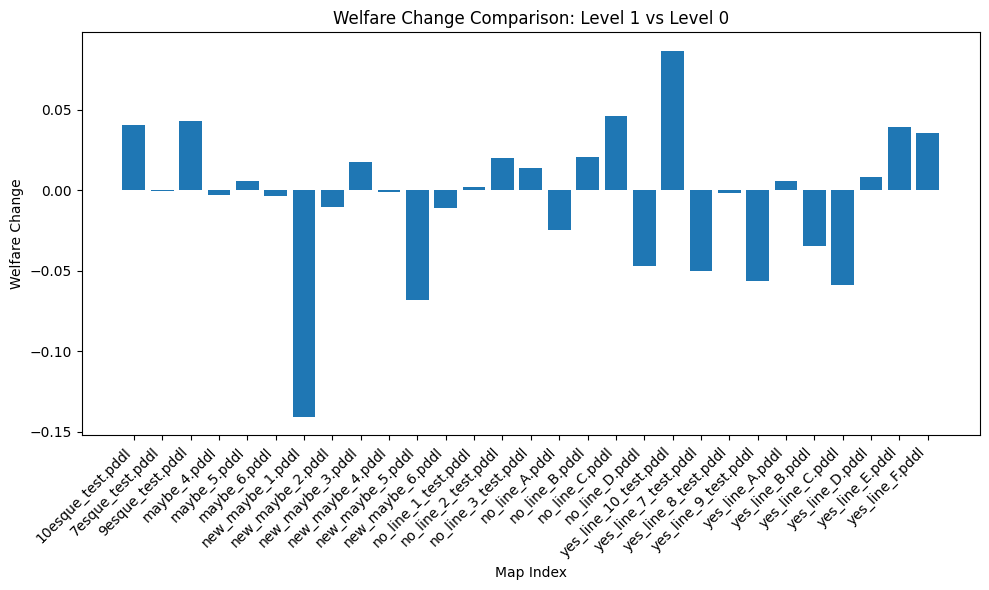

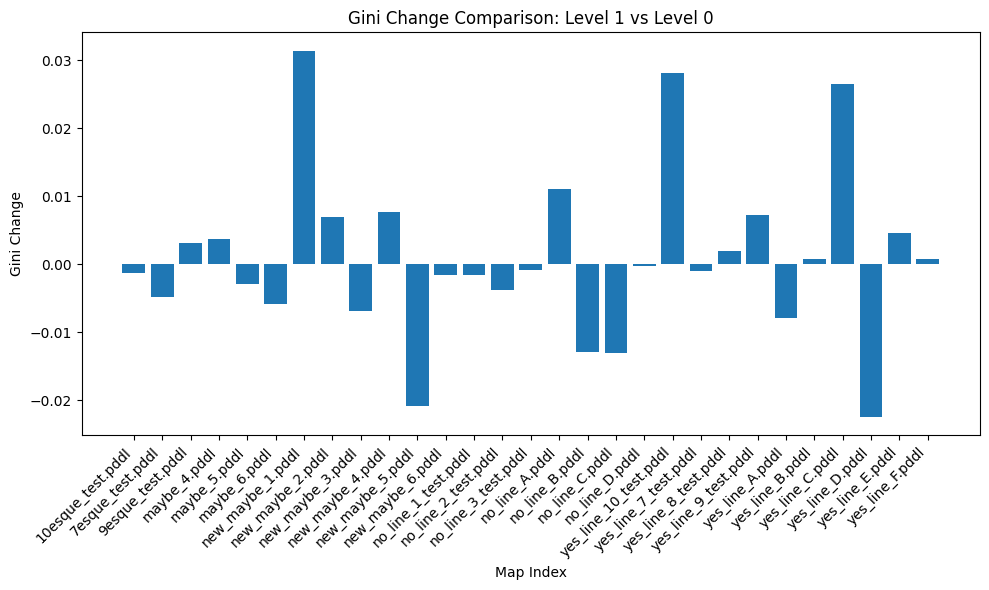

In [52]:
# # Plot results
if all_results is not None:
     analyzer.plot_comparison(all_results, 'welfare_change')
     analyzer.plot_comparison(all_results, 'gini_change')

In [55]:
analyzer.compare_map("yes_line_10_test.pddl")
analyzer.compare_map("maybe_6.pddl")


=== Comparison for yes_line_10_test.pddl ===
Level 0 - Mean: 89.5, Std: 35.1
Level 1 - Mean: 81.8, Std: 35.5
Welfare change (L1 vs L0): 0.087
Raw inequality L0: 97.8, L1: 99.2
Normalized inequality change (paper method): 0.010
Gini coefficient change: 0.028

=== Comparison for maybe_6.pddl ===
Level 0 - Mean: 30.9, Std: 5.0
Level 1 - Mean: 31.0, Std: 4.6
Welfare change (L1 vs L0): -0.003
Raw inequality L0: 16.0, L1: 15.0
Normalized inequality change (paper method): -0.026
Gini coefficient change: -0.006


{'map': 'maybe_6.pddl',
 'welfare_change': np.float64(-0.0032336297493936253),
 'raw_inequality_l0': np.float64(16.0),
 'raw_inequality_l1': np.float64(15.0),
 'inequality_change': np.float64(-0.025641025641025605),
 'gini_change': np.float64(-0.005857193803522301),
 'mean_time_l0': np.float64(30.925),
 'mean_time_l1': np.float64(31.025)}